# Housing Prices Preduction

##### Housing prices are among the most notoriously difficult to predict. In this notebook, the housing market prices of the Boston area, U.S is predicted. In conclusion, the models built here are sufficiently reliable for various stakehodlers in informing them the most likely prices to be seen.



### Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error



### Loading datasets

In [2]:
df_houses = pd.read_csv('data_zillow_house_prices.csv')
df_interest = pd.read_csv('data_interest_rates.csv')

In [3]:
df_houses.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2021-11-30,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31
0,102001,0,United States,country,NaN,127881.0,128227.0,128591.0,129332.0,130079.0,...,318303.0,322658.0,327381.0,332588.0,337848.0,343392.0,348415.0,352585.0,354986.0,356026.0
1,394913,1,"New York, NY",msa,NY,224676.0,226018.0,227226.0,229604.0,231817.0,...,573600.0,576842.0,580804.0,585445.0,591876.0,599008.0,606525.0,612535.0,616856.0,619142.0
2,753899,2,"Los Angeles, CA",msa,CA,227786.0,228579.0,229794.0,232104.0,234580.0,...,845860.0,855023.0,865646.0,877802.0,895038.0,914016.0,930381.0,931707.0,928599.0,914636.0
3,394463,3,"Chicago, IL",msa,IL,170004.0,170405.0,170924.0,171963.0,173064.0,...,288807.0,291527.0,294162.0,296729.0,300023.0,303490.0,307454.0,310438.0,312286.0,312609.0
4,394514,4,"Dallas, TX",msa,TX,129921.0,130025.0,130112.0,130323.0,130544.0,...,337274.0,343129.0,350514.0,358982.0,367040.0,376487.0,385149.0,392668.0,394861.0,393920.0


In [4]:
df_interest.head()

,DATE,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


### Data Preparation

In [3]:
df_houses = df_houses.melt( id_vars=['RegionID','SizeRank','RegionName','StateName','RegionType']).\
rename(columns={'variable':'Date','value':'Price'})
df_house = df_houses.loc[df_houses.RegionName == 'Boston, MA']
df_house['Date'] = pd.to_datetime(df_house['Date'])
df_house.set_index('Date',inplace=True)

C:\Users\Weld_\AppData\Local\Temp\ipykernel_2972\1259820074.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_house['Date'] = pd.to_datetime(df_house['Date'])


### Creating the training and testing sets

In [6]:
df_house_training = df_house['01-01-2010':'12-31-2017']
df_house_test = df_house['01-01-2018':'12-31-2019']

#### We first investigate the series graphically to understand its processes better

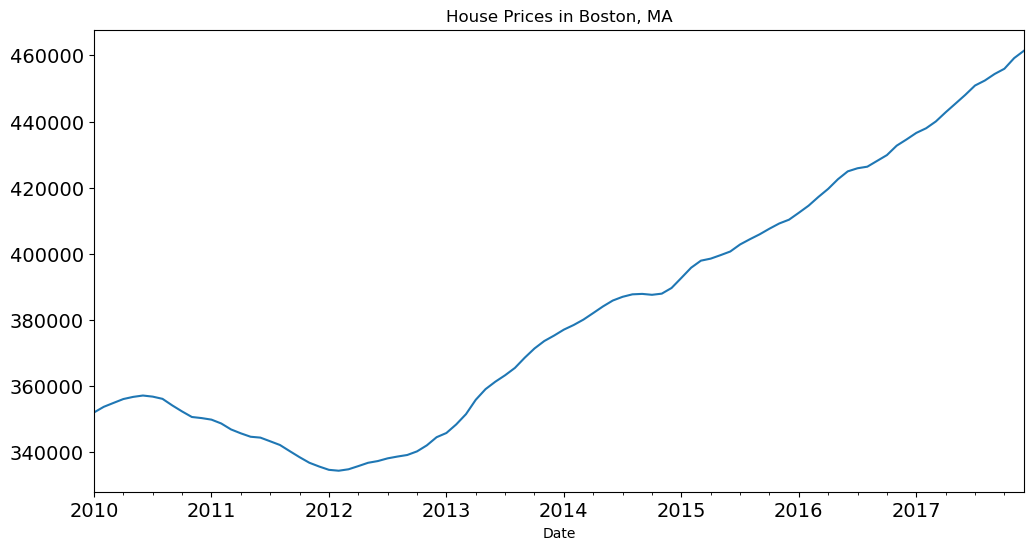

In [7]:
df_house_training['Price'].plot(figsize=(12,6), title='House Prices in Boston, MA', fontsize=14)
plt.show()

There is clear trend. This means that the series or processes is non stationary. This implies additional treatments before modelling.

### Modeling

We proceed with implmenting Autoregressive models. First without any exogenous variables and later on with the addition of interest rates. Later, the final exercise is to change the training and testing periods to be during the time of COVID. 

### AR(1) Model

Because of the trend seen in the series, we first detrend it.

In [9]:

train_ols = df_house.loc['01-01-2010':'12-31-2017'].copy()
train_ols['trend'] = np.arange(1, len(train_ols) + 1)
X = train_ols[['trend']]
y = train_ols['Price']
X = sm.add_constant(X)
model = OLS(y,X).fit()
detrended_training = model.resid
detrended_test = df_house.loc['01-01-2018':'12-31-2019']['Price'] - (model.params[0] + model.params[1] * np.arange(len(train_ols) + 1, len(train_ols) + 1 + len(df_house.loc['01-01-2018':'12-31-2019'])))
detrended = pd.concat([detrended_training, detrended_test])



C:\Users\Weld_\AppData\Local\Temp\ipykernel_17844\3526584226.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  detrended_test = df_house.loc['01-01-2018':'12-31-2019']['Price'] - (model.params[0] + model.params[1] * np.arange(len(train_ols) + 1, len(train_ols) + 1 + len(df_house.loc['01-01-2018':'12-31-2019'])))


#### Fitting Autoregression with order 1

c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


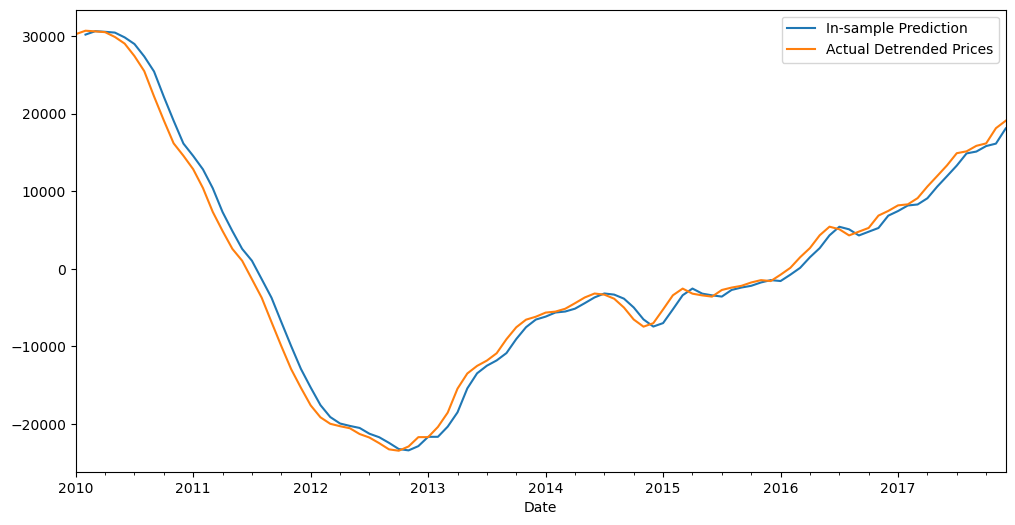

Training Mean Squared Error: 11.573506500322601


In [10]:
warnings.simplefilter("ignore", ConvergenceWarning)
model = ARIMA(detrended['01-01-2010':'12-31-2017'], order=(1,0,0)).fit()
in_sample_pred = model.fittedvalues
plt.figure(figsize=(12,6))
in_sample_pred['02-01-2010':'12-31-2017'].plot(label='In-sample Prediction')
detrended['01-01-2010':'12-31-2017'].plot(label='Actual Detrended Prices')
plt.legend()
plt.show()
print("Training Mean Squared Error:", mean_squared_error(detrended_training, in_sample_pred['01-01-2010':'12-31-2017'])/1000000)



## Time-Series Prediction With Exogenous Inputs

We will introduce an additional variable: Interest Rates!

C:\Users\Weld_\AppData\Local\Temp\ipykernel_2972\225980229.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_interest_monthly = df_interest.resample('M').mean()


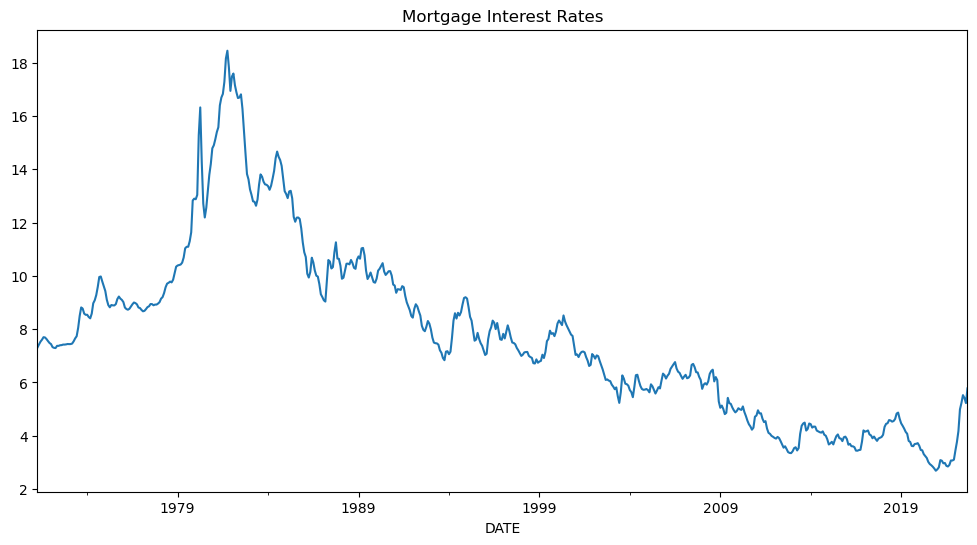

In [5]:
df_interest['DATE'] = pd.to_datetime(df_interest['DATE'])
df_interest.set_index('DATE', inplace=True)
df_interest_monthly = df_interest.resample('M').mean()
plt.figure(figsize=(12,6))
df_interest_monthly['MORTGAGE30US'].plot()
plt.title('Mortgage Interest Rates')
plt.show()


### ARX

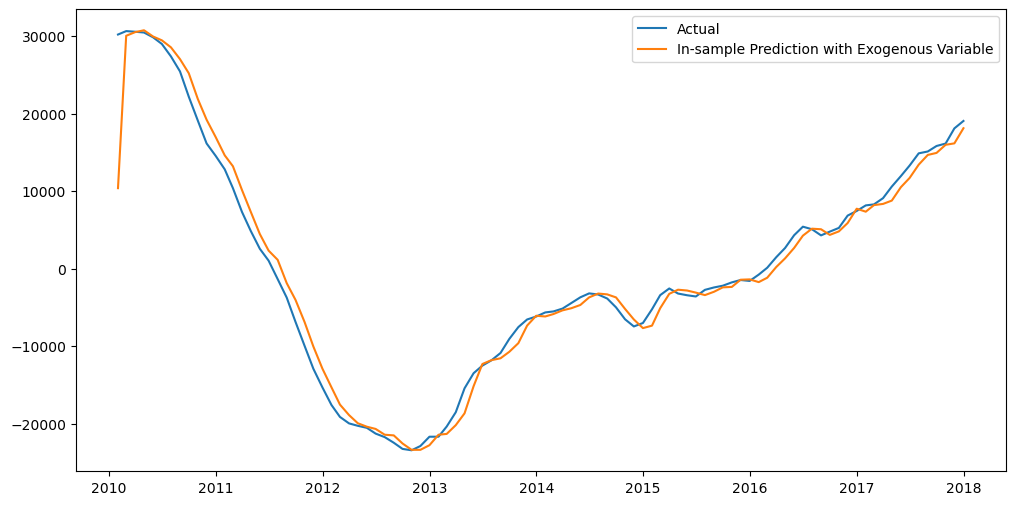

Mean Squared Error: 6.093789441371887


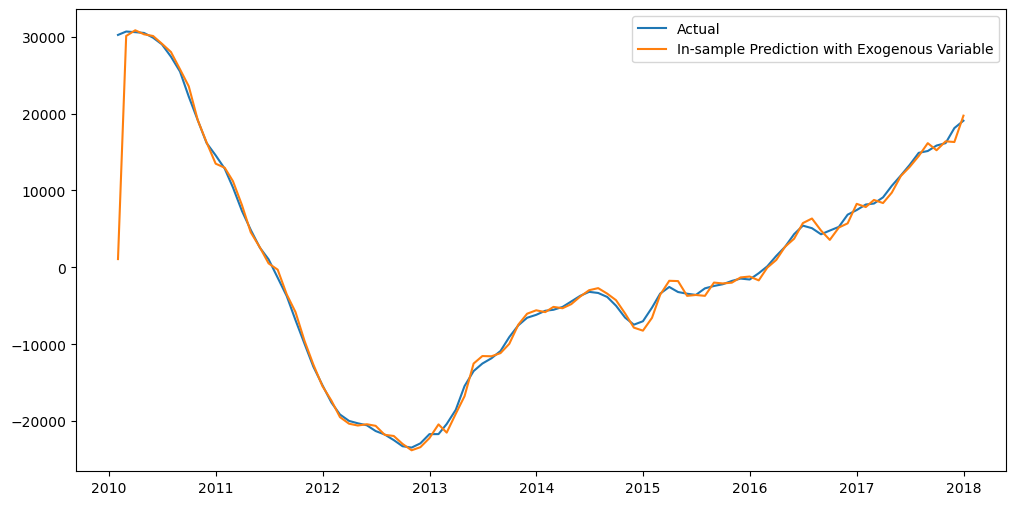

Mean Squared Error: 9.276633511392149


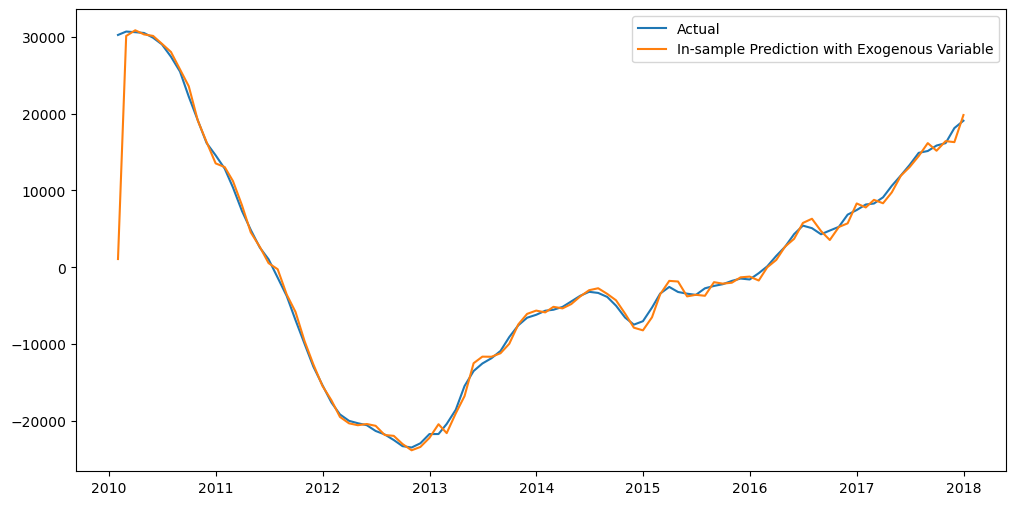

Mean Squared Error: 9.27442765586181


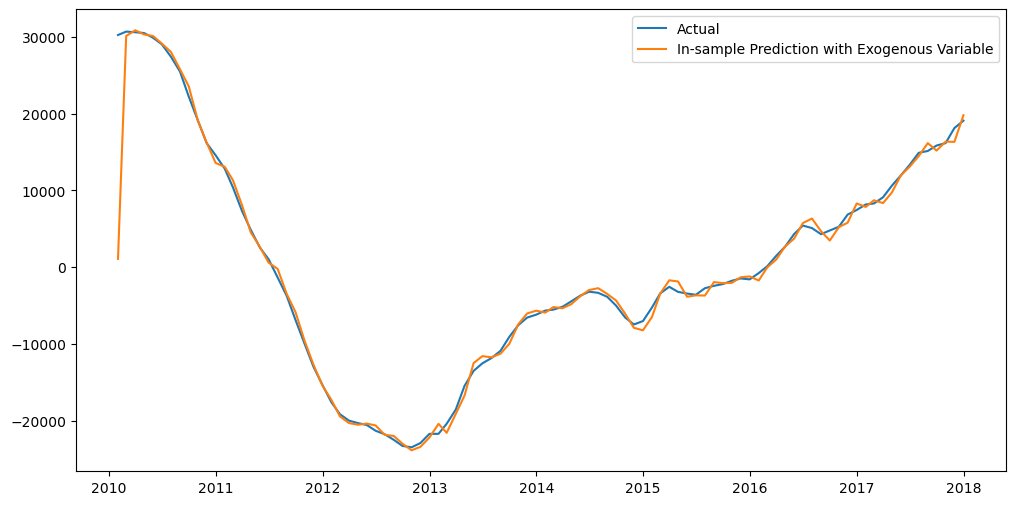

Mean Squared Error: 9.268666118238736


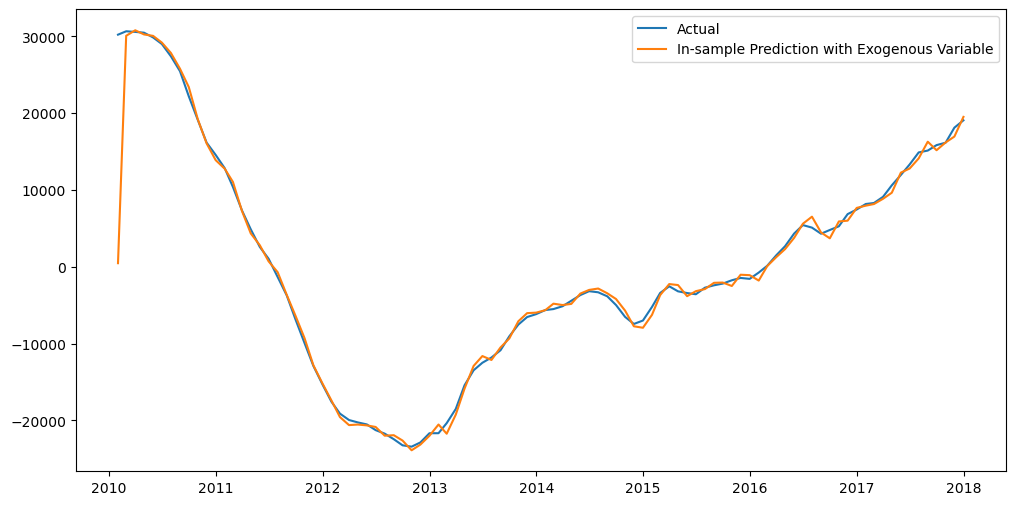

Mean Squared Error: 9.54234150464609


In [29]:
for p in range(1,6):
    model = ARIMA(endog = detrended['01-01-2010':'12-31-2017'], order=(p,0,0),trend='n', exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':'12-31-2017']
              ).fit()
    in_sample_pred = model.fittedvalues
    plt.figure(figsize=(12,6))
    plt.plot(detrended['01-01-2010':'12-31-2017'], label='Actual')
    plt.plot(in_sample_pred['01-01-2010':'12-31-2017'], label='In-sample Prediction with Exogenous Variable')
    plt.legend()
    plt.show()
    print("Mean Squared Error:", mean_squared_error(detrended['01-01-2010':'12-31-2017'], in_sample_pred['01-01-2010':'12-31-2017'])/1000000)

### Out of sample predictions. 
The main stratergy used is the one step predictions. This means that at each point, we are only predicting one step ahead, and then retraining with additional observations.

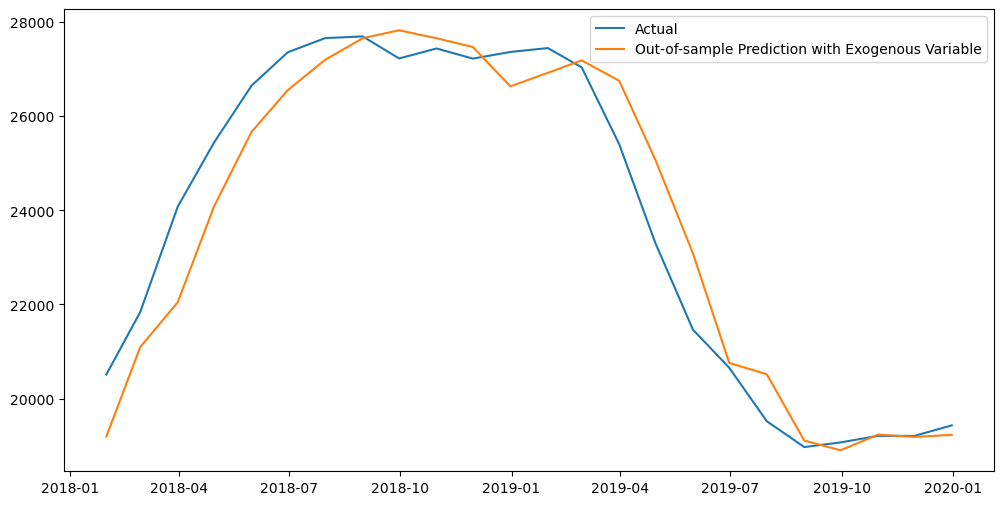

Mean Squared Error (In-sample): 5.249391402559684
Mean Squared Error (Out-of-sample): 0.8354170812881984


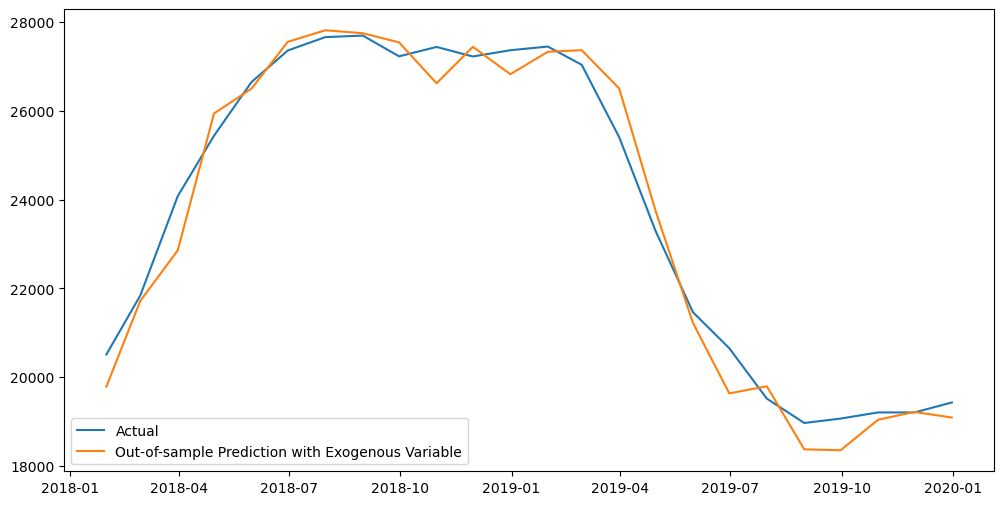

Mean Squared Error (In-sample): 9.941247694778426
Mean Squared Error (Out-of-sample): 0.29936332618413314


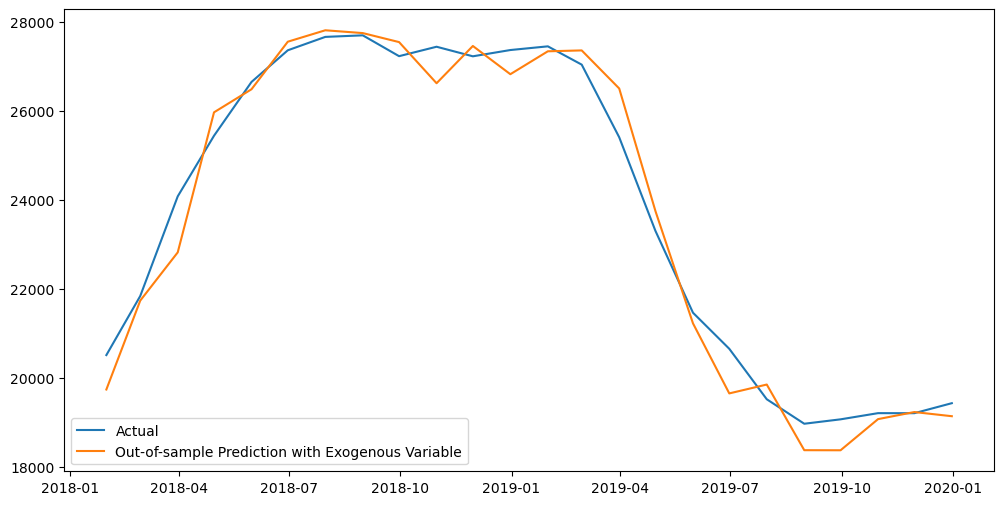

Mean Squared Error (In-sample): 6.192784732274157
Mean Squared Error (Out-of-sample): 0.30436396872817195


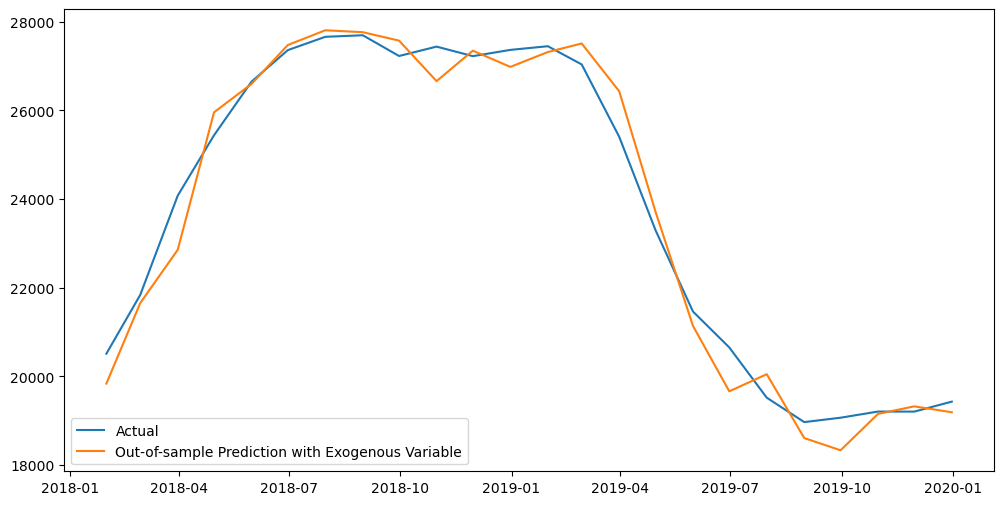

Mean Squared Error (In-sample): 9.934496518569365
Mean Squared Error (Out-of-sample): 0.2816759395234502


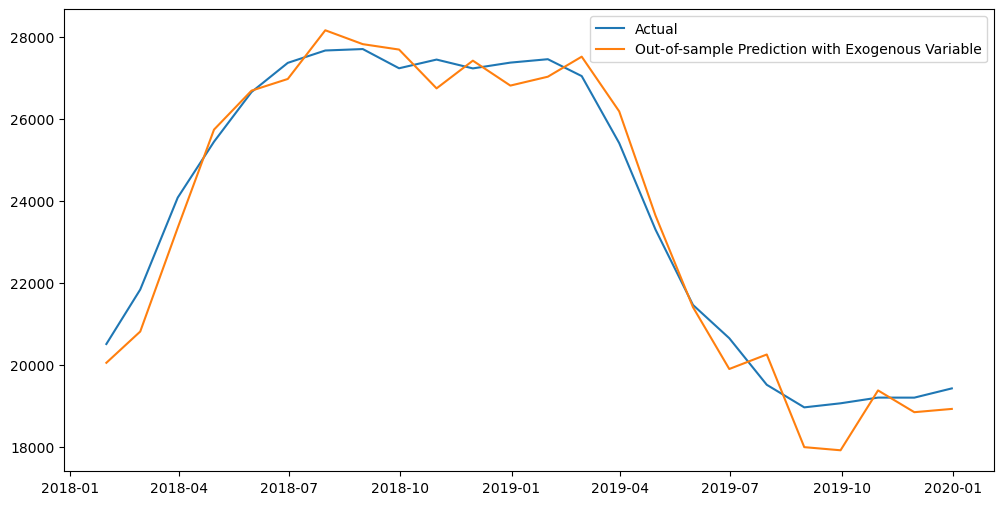

Mean Squared Error (In-sample): 6.118057896758248
Mean Squared Error (Out-of-sample): 0.34251116389879926


In [30]:
for p in range(1,6):
    model = ARIMA(endog = detrended_training['01-01-2010':'12-31-2017'], order=(p,0,0),trend='n', exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':'12-31-2017']
              ).fit()
    prediction = {}
    for i in range(len(detrended_test)):
        model = ARIMA(endog = detrended.iloc[:len(detrended_training) + i],order=(p,0,0),trend='n', exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':].iloc[:len(detrended_training) + i]
              ).fit()
        pred = model.forecast(steps=1, exog= df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':].iloc[len(detrended_training) + i:len(detrended_training) + i + 1])
        prediction[pred.index[0]] = pred.values[0]
    in_sample_pred = model.fittedvalues
    df_pred = pd.Series(prediction)
    plt.figure(figsize=(12,6))
    plt.plot(detrended_test['01-01-2018':'12-31-2019'], label='Actual')
    plt.plot(df_pred, label='Out-of-sample Prediction with Exogenous Variable')
    plt.legend()
    plt.show()
    print("Mean Squared Error (In-sample):", mean_squared_error(detrended_training, in_sample_pred['01-01-2010':'12-31-2017'])/1000000)
    print("Mean Squared Error (Out-of-sample):", mean_squared_error(detrended_test['01-01-2018':'12-31-2019'], df_pred['01-01-2018':'12-31-2019'])/1000000)
    

## ARMX model


This is an Autoregressie Moving Average model with exogenous variable. Let's test for different values of p and q orders.

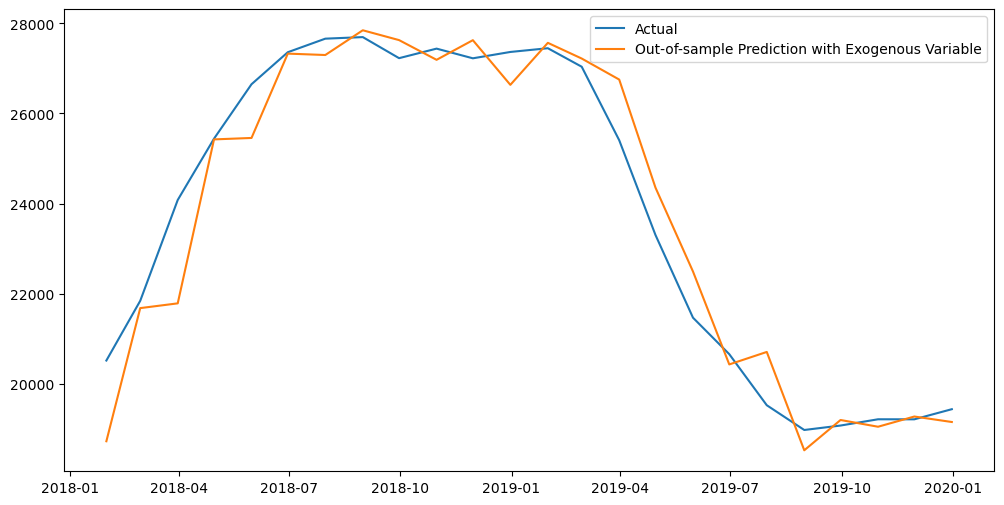

ARIMA(1,0,1) with Exogenous Variable
6.202305722939365
0.7005777541519798


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting par

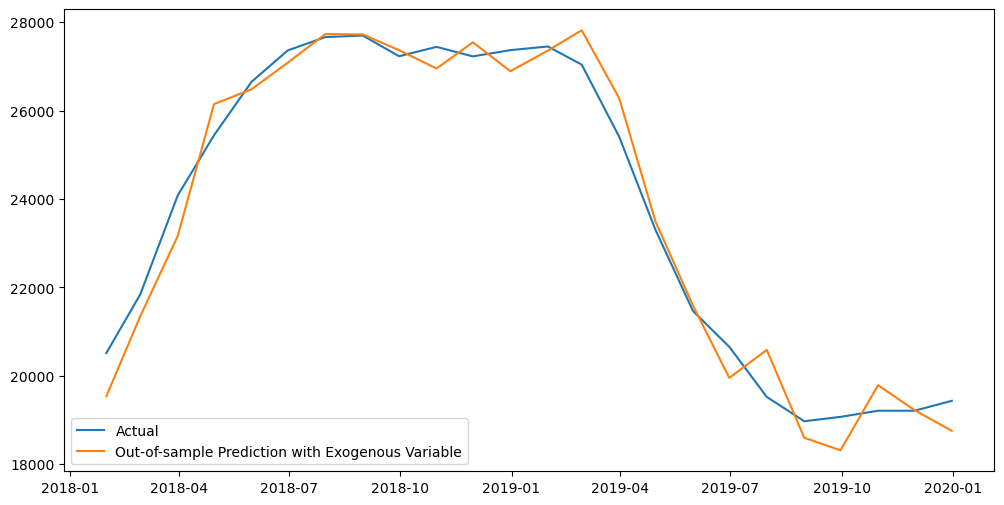

ARIMA(1,0,5) with Exogenous Variable
9.26073138613694
0.32480891029342945


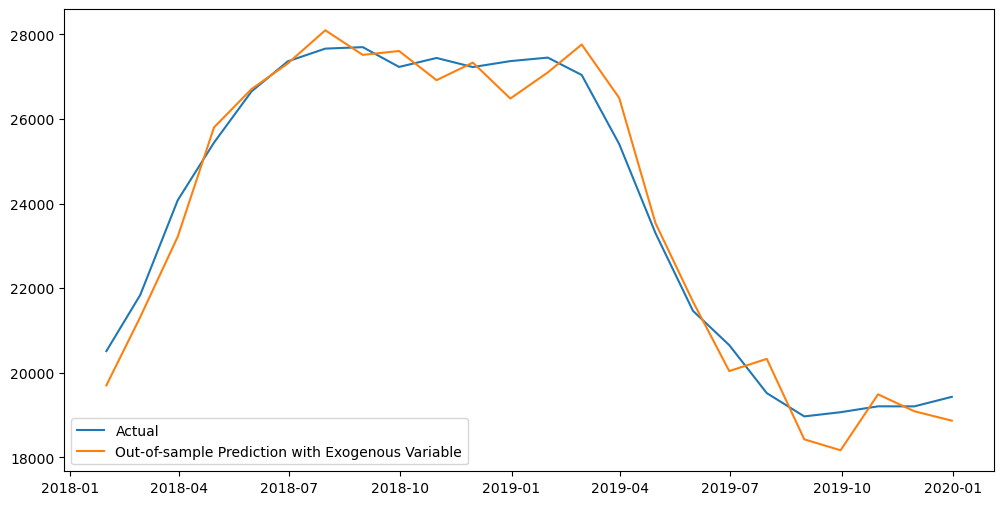

ARIMA(1,0,10) with Exogenous Variable
9.155980278030288
0.3213955663102025


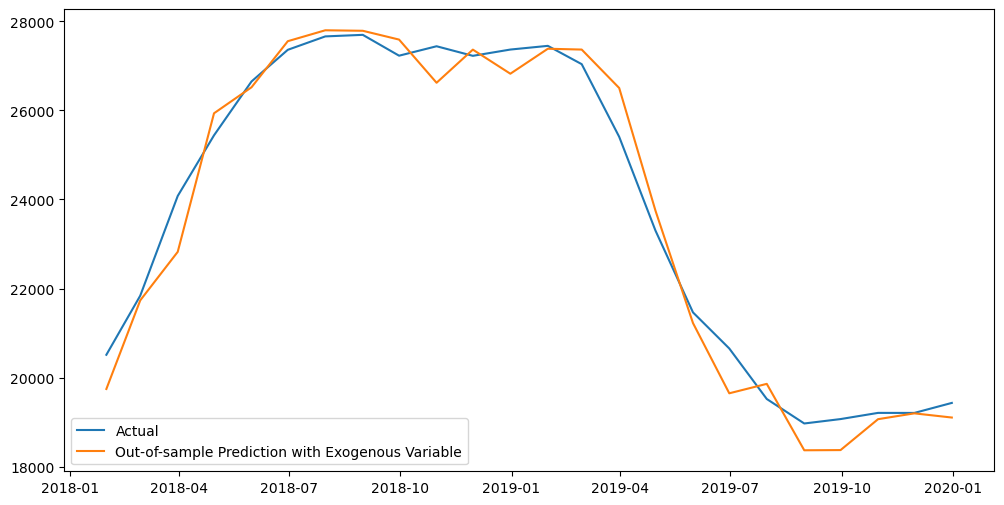

ARIMA(2,0,1) with Exogenous Variable
9.269985091960494
0.30380019854255524


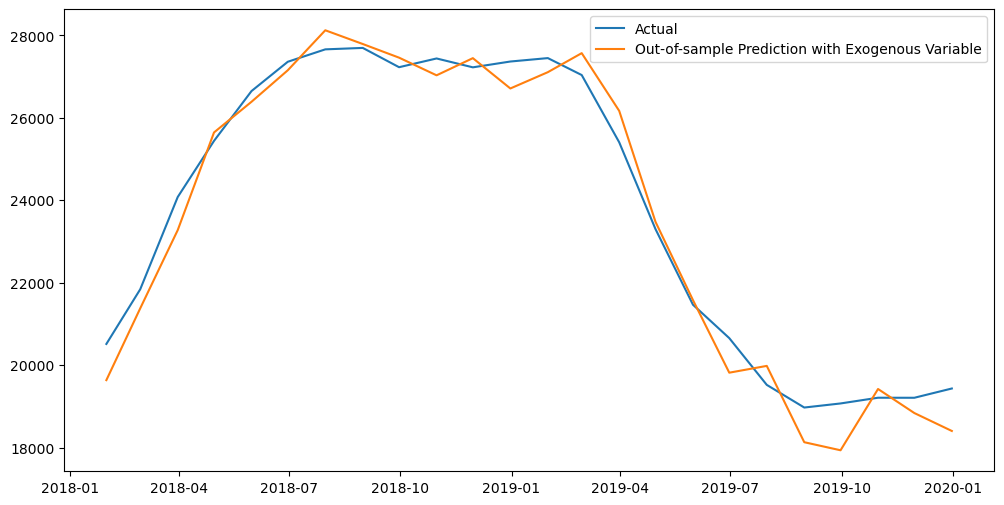

ARIMA(2,0,5) with Exogenous Variable
9.134418873584872
0.3285021949690523


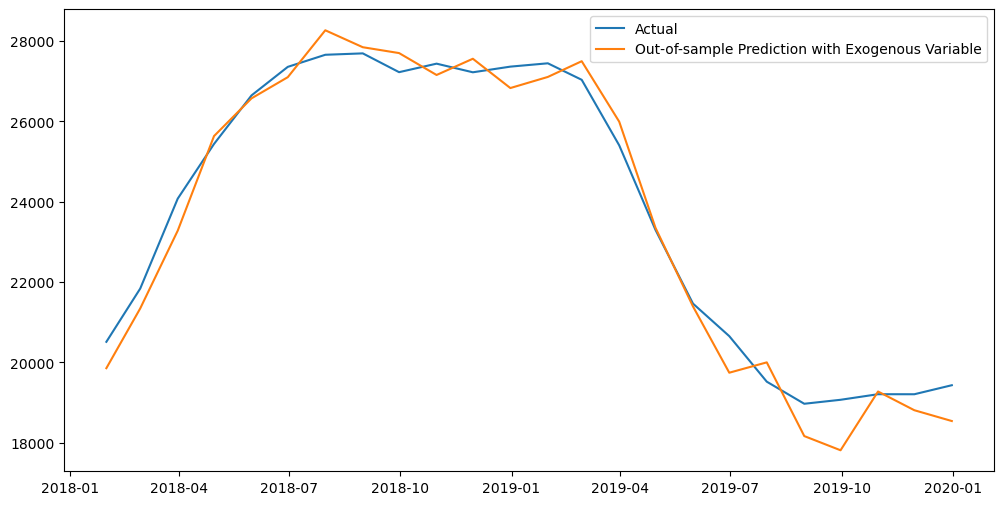

ARIMA(2,0,10) with Exogenous Variable
9.109589966520572
0.3106408453794737


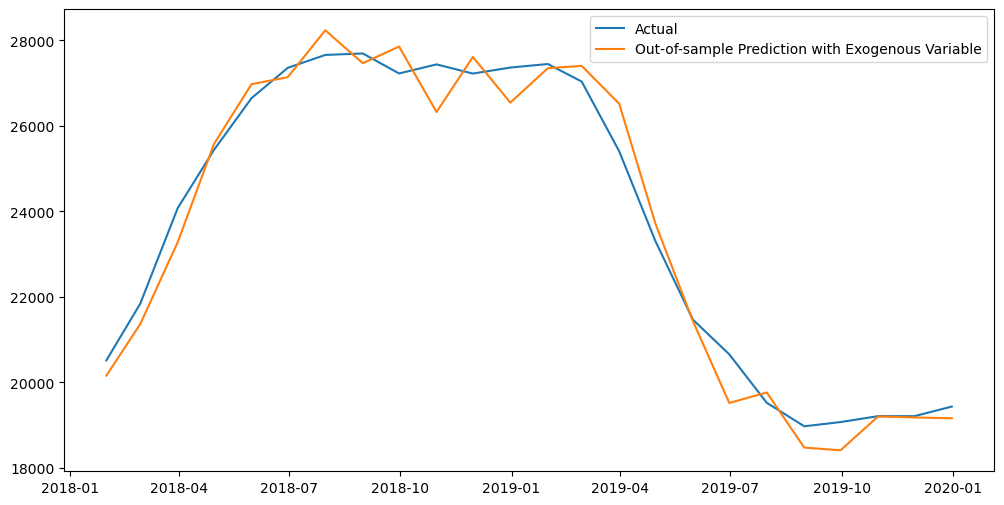

ARIMA(3,0,1) with Exogenous Variable
10.33917773160594
0.3201222453821356


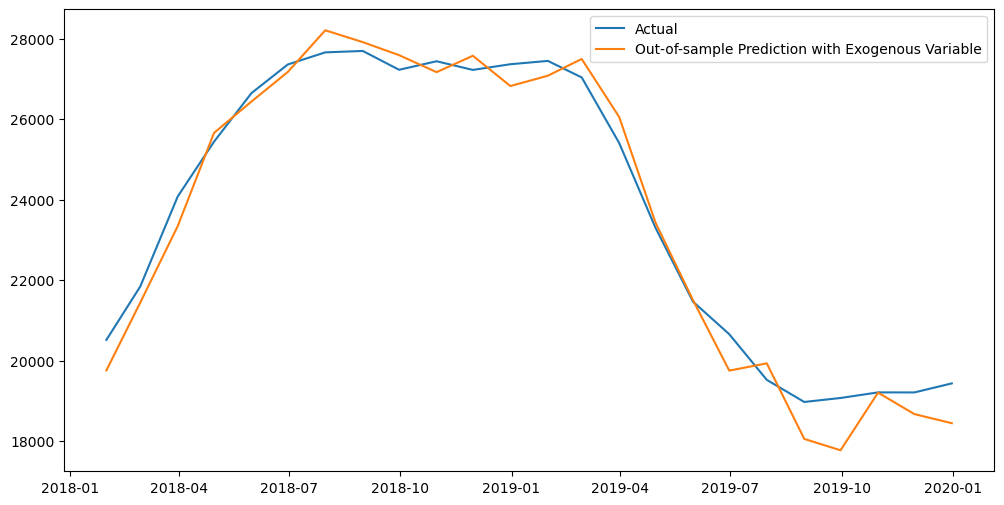

ARIMA(3,0,5) with Exogenous Variable
9.116881813962811
0.33123956520035946


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


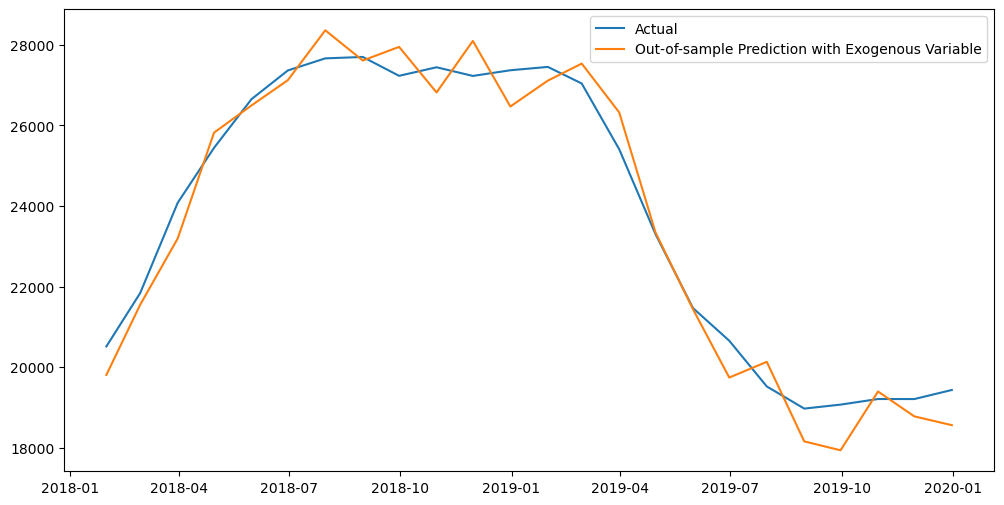

ARIMA(3,0,10) with Exogenous Variable
9.096972415113298
0.41213729172483243


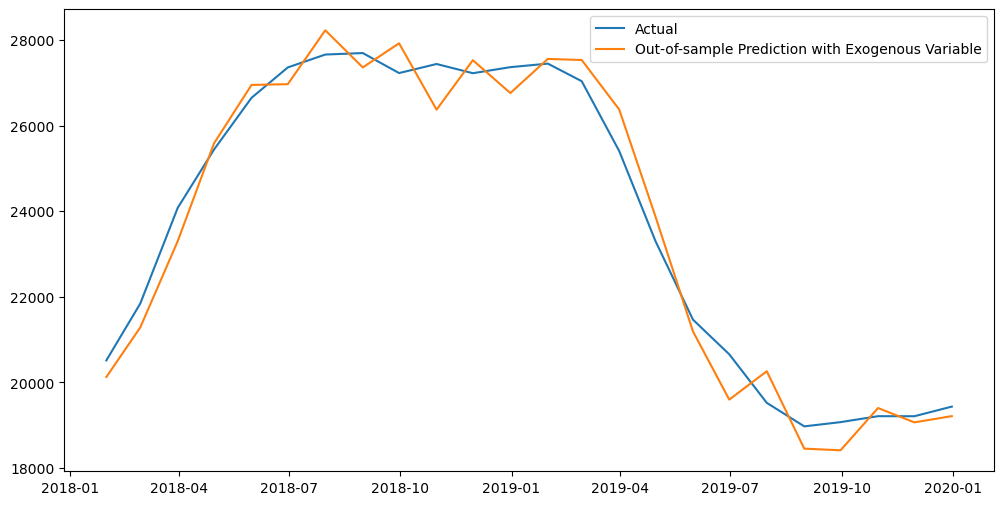

ARIMA(4,0,1) with Exogenous Variable
9.249127711244528
0.3305190180040917


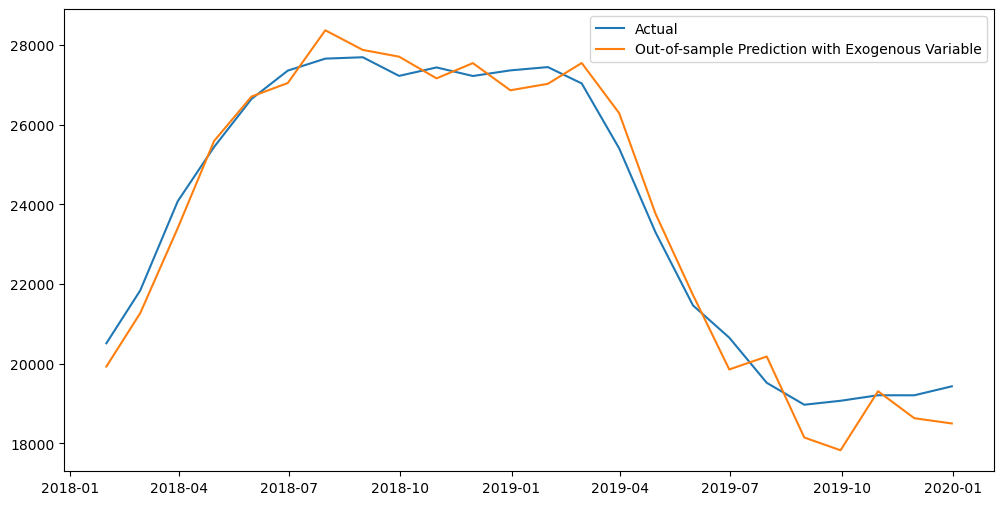

ARIMA(4,0,5) with Exogenous Variable
9.115023669764005
0.3526574425177454


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


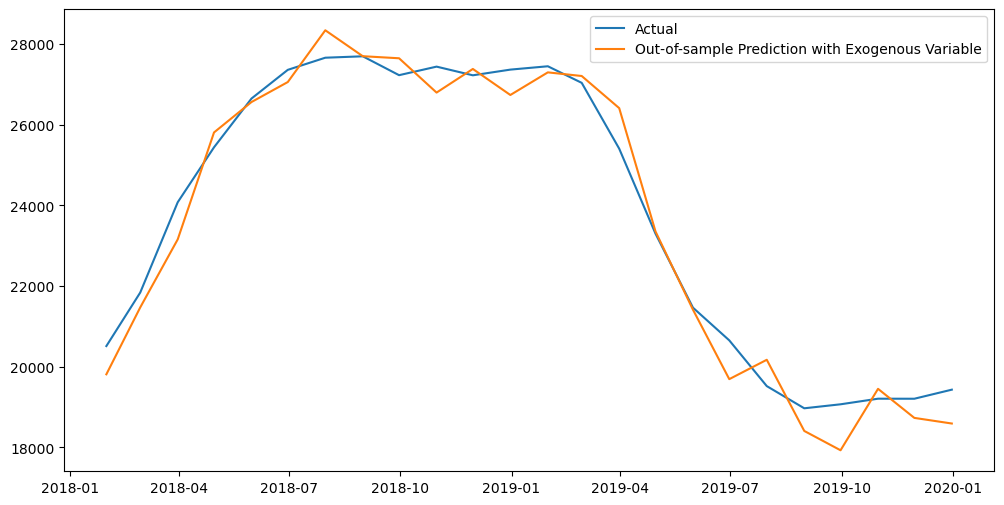

ARIMA(4,0,10) with Exogenous Variable
9.086302188668887
0.3417131898909252


In [ ]:

for p in range(1,5):
    for q in [1,5,10]:
        model = ARIMA(detrended_training,trend='n',exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':'12-31-2017'], order=(p,0,q)).fit()
        in_sample_pred = model.fittedvalues
        prediction = {}
        for i in range(len(detrended_test)):
            model = ARIMA(endog = detrended.iloc[:len(detrended_training) + i],order=(p,0,q),trend='n', exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':].iloc[:len(detrended_training) + i]
              ).fit()
            pred = model.forecast(steps=1, exog= df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':].iloc[len(detrended_training) + i:len(detrended_training) + i + 1])
            prediction[pred.index[0]] = pred.values[0]
        df_pred = pd.Series(prediction)
        plt.figure(figsize=(12,6))
        plt.plot(detrended_test['01-01-2018':'12-31-2019'], label='Actual')
        plt.plot(df_pred, label='Out-of-sample Prediction with Exogenous Variable')
        plt.legend()
        plt.show()
        print(f'ARIMA({p},0,{q}) with Exogenous Variable')
        print("Mean Squared Error (In-sample):", mean_squared_error(detrended_training, in_sample_pred['01-01-2010':'12-31-2017'])/1000000)
        print("Mean Squared Error (Out-of-sample):", mean_squared_error(detrended_test['01-01-2018':'12-31-2019'], df_pred['01-01-2018':'12-31-2019'])/1000000)
        warnings.simplefilter("ignore", ConvergenceWarning)

## Different Period



We will now change the training and testing period and assess the best model given this change. The new training period will be January 1st 2010 to December 31 2019. Testing period will be January 1st 2020 to December 31st 2021. 

### AR(2)

C:\Users\Weld_\AppData\Local\Temp\ipykernel_5048\2998955647.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  detrended_test = df_house.loc['01-01-2020':'12-31-2021']['Price'] - (model.params[0] + model.params[1] * np.arange(len(train_ols) + 1, len(train_ols) + 1 + len(df_house.loc['01-01-2020':'12-31-2021'])))
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-pac

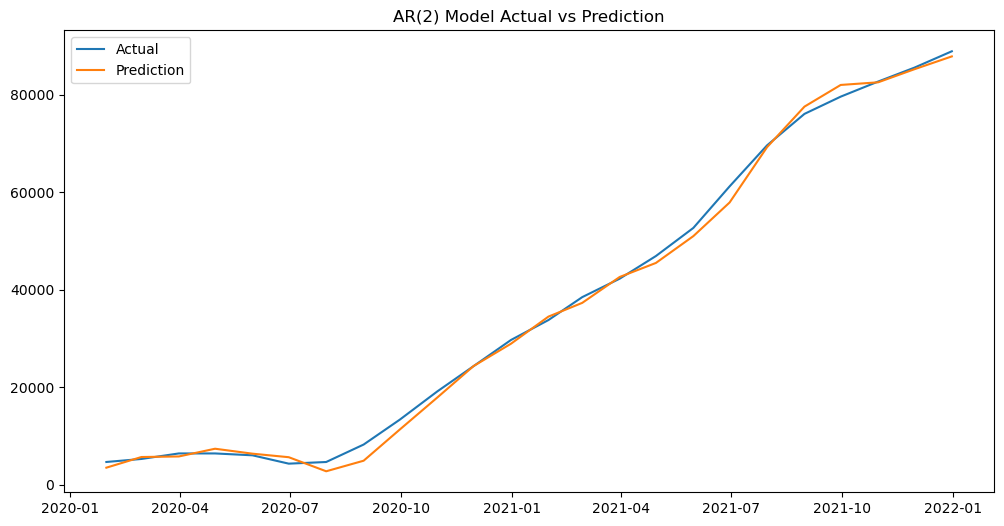

Mean Squared Error (In-sample): 11.587011237162562
Mean Squared Error (Out-of-sample): 2.193317010409466


In [52]:

train_ols = df_house.loc['01-01-2010':'12-31-2019'].copy()
train_ols['trend'] = np.arange(1, len(train_ols) + 1)
X = train_ols[['trend']]
y = train_ols['Price']
X = sm.add_constant(X)
model = OLS(y,X).fit()
detrended_train = model.resid
detrended_test = df_house.loc['01-01-2020':'12-31-2021']['Price'] - (model.params[0] + model.params[1] * np.arange(len(train_ols) + 1, len(train_ols) + 1 + len(df_house.loc['01-01-2020':'12-31-2021'])))
detrended = pd.concat([detrended_train, detrended_test])
prediction = {}
train = detrended['01-01-2010':'12-31-2019']
test = detrended['01-01-2020':'12-31-2021']
model = ARIMA(endog = train, order=(2,0,0),trend='n').fit()
in_sample_pred = model.fittedvalues
for i in range(len(test)):
    model = ARIMA(endog = detrended.iloc[:len(train) + i],order=(2,0,0),trend='n').fit()
    pred = model.forecast(steps=1)
    prediction[pred.index[0]] = pred.values[0]
post_covid_train_mse = mean_squared_error(train, in_sample_pred)
post_covid_test_mse = mean_squared_error(test, pd.Series(prediction))
plt.figure(figsize=(12,6))
plt.plot(detrended['01-01-2020':'12-31-2021'], label='Actual')
plt.plot(pd.Series(prediction), label='Prediction')
plt.title('AR(2) Model Actual vs Prediction')
plt.legend()
plt.show()
print("Mean Squared Error (In-sample):", post_covid_train_mse / 1000000)
print("Mean Squared Error (Out-of-sample):", post_covid_test_mse / 1000000)

Comparison between Pre and Post Covid AR(2)

In [60]:
print("Pre-COVID Mean Squared Error (In-sample):", pre_covid_train_mse )
print("Pre-COVID Mean Squared Error (Out-of-sample):", pre_covid_test_mse )

print("Post-COVID Mean Squared Error (In-sample):", post_covid_train_mse )
print("Post-COVID Mean Squared Error (Out-of-sample):", post_covid_test_mse)

print("Post Covid prediction accuracy degraded by", (post_covid_test_mse / pre_covid_test_mse - 1) * 100, "% compared to pre-COVID performance.")

Pre-COVID Mean Squared Error (In-sample): 9942713.48727037
Pre-COVID Mean Squared Error (Out-of-sample): 297840.27312436217
Post-COVID Mean Squared Error (In-sample): 11587011.237162562
Post-COVID Mean Squared Error (Out-of-sample): 2193317.010409466
Post Covid prediction accuracy degraded by 636.4071310442473 % compared to pre-COVID performance.


### AR(X)

C:\Users\Weld_\AppData\Local\Temp\ipykernel_5048\1564544541.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  detrended_test = df_house.loc['01-01-2020':'12-31-2021']['Price'] - (model.params[0] + model.params[1] * np.arange(len(train_ols) + 1, len(train_ols) + 1 + len(df_house.loc['01-01-2020':'12-31-2021'])))


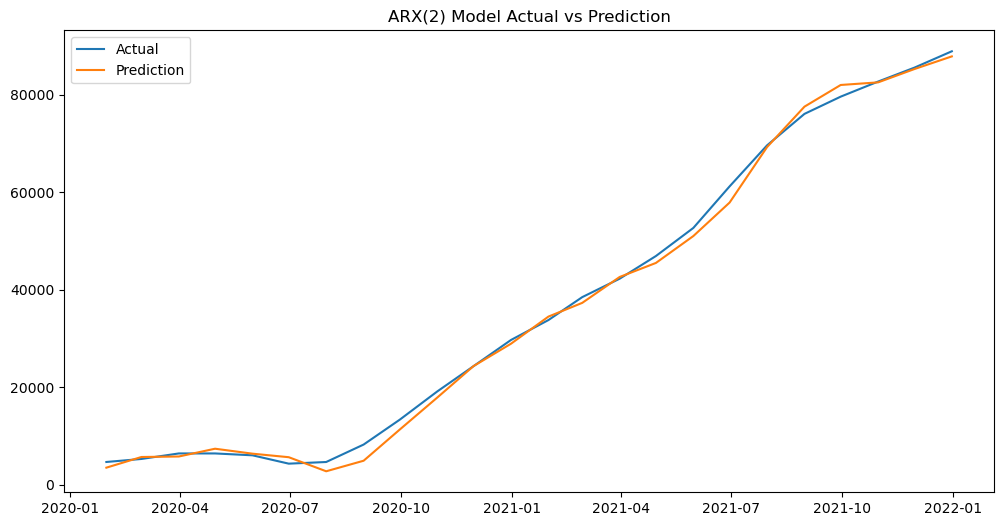

Mean Squared Error (In-sample): 11.664698876845037
Mean Squared Error (Out-of-sample): 2.1931605910228056


In [63]:
train_ols = df_house.loc['01-01-2010':'12-31-2019'].copy()
train_ols['trend'] = np.arange(1, len(train_ols) + 1)
X = train_ols[['trend']]
y = train_ols['Price']
X = sm.add_constant(X)
model = OLS(y,X).fit()
detrended_train = model.resid
detrended_test = df_house.loc['01-01-2020':'12-31-2021']['Price'] - (model.params[0] + model.params[1] * np.arange(len(train_ols) + 1, len(train_ols) + 1 + len(df_house.loc['01-01-2020':'12-31-2021'])))
detrended = pd.concat([detrended_train, detrended_test])
prediction = {}
train = detrended['01-01-2010':'12-31-2019']
test = detrended['01-01-2020':'12-31-2021']
model = ARIMA(endog = train, order=(2,0,0),trend='n', exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':'12-31-2019']).fit()
in_sample_pred = model.fittedvalues
for i in range(len(test)):
    model = ARIMA(endog = detrended.iloc[:len(train) + i],order=(2,0,0),trend='n', exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':].iloc[:len(train) + i]
              ).fit()
    pred = model.forecast(steps=1, exog= df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':].iloc[len(train) + i:len(train) + i + 1])
    prediction[pred.index[0]] = pred.values[0]
post_covid_train_mse = mean_squared_error(train, in_sample_pred)
post_covid_test_mse = mean_squared_error(test, pd.Series(prediction))
plt.figure(figsize=(12,6))
plt.plot(detrended['01-01-2020':'12-31-2021'], label='Actual')
plt.plot(pd.Series(prediction), label='Prediction')
plt.title('ARX(2) Model Actual vs Prediction')
plt.legend()
plt.show()
print("Mean Squared Error (In-sample):", mean_squared_error(train, in_sample_pred)/1000000)
print("Mean Squared Error (Out-of-sample):", mean_squared_error(test, pd.Series(prediction)) / 1000000)

In [64]:
print("Pre-COVID Mean Squared Error (In-sample) for ARX(2):", pre_covid_train_mse)
print("Pre-COVID Mean Squared Error (Out-of-sample) for ARX(2):", pre_covid_test_mse)
print("Post-COVID Mean Squared Error (In-sample) for ARX(2):", post_covid_train_mse)
print("Post-COVID Mean Squared Error (Out-of-sample) for ARX(2):", post_covid_test_mse)

print("Post Covid prediction accuracy degraded by", (post_covid_test_mse / pre_covid_test_mse - 1) * 100, "% compared to pre-COVID performance.")

Pre-COVID Mean Squared Error (In-sample) for ARX(2): 9276633.511392148
Pre-COVID Mean Squared Error (Out-of-sample) for ARX(2): 639235.2776941106
Post-COVID Mean Squared Error (In-sample) for ARX(2): 11664698.876845038
Post-COVID Mean Squared Error (Out-of-sample) for ARX(2): 2193160.591022806
Post Covid prediction accuracy degraded by 243.09129479432227 % compared to pre-COVID performance.


### ARMX

C:\Users\Weld_\AppData\Local\Temp\ipykernel_2972\2173658979.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  detrended_test = df_house.loc['01-01-2020':'12-31-2021']['Price'] - (model.params[0] + model.params[1] * np.arange(len(train_ols) + 1, len(train_ols) + 1 + len(df_house.loc['01-01-2020':'12-31-2021'])))
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Weld_\

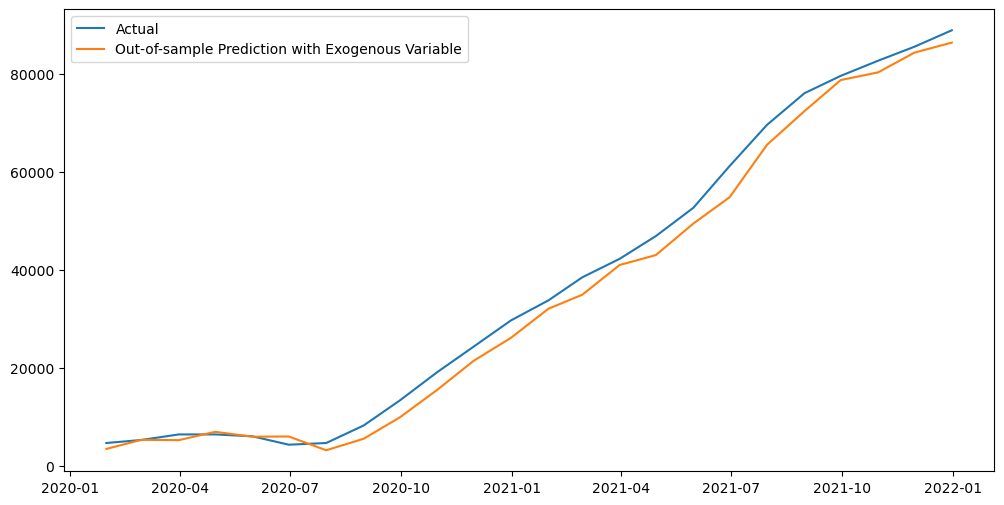

ARIMA(1,0,1) with Exogenous Variable
Mean Squared Error (In-sample): 8.421416153805131
Mean Squared Error (Out-of-sample): 7.851973562574726


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting par

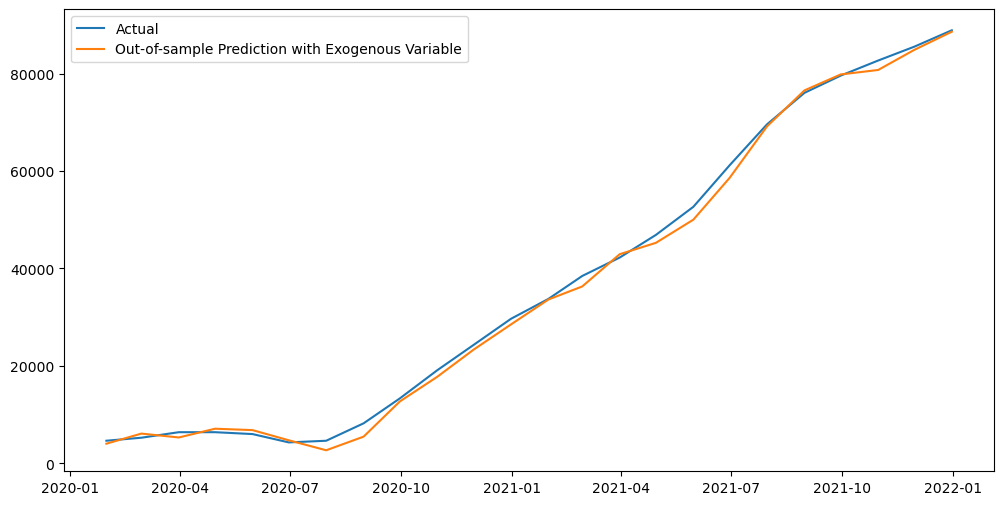

ARIMA(1,0,5) with Exogenous Variable
Mean Squared Error (In-sample): 11.879147775357133
Mean Squared Error (Out-of-sample): 1.897326194791424


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting par

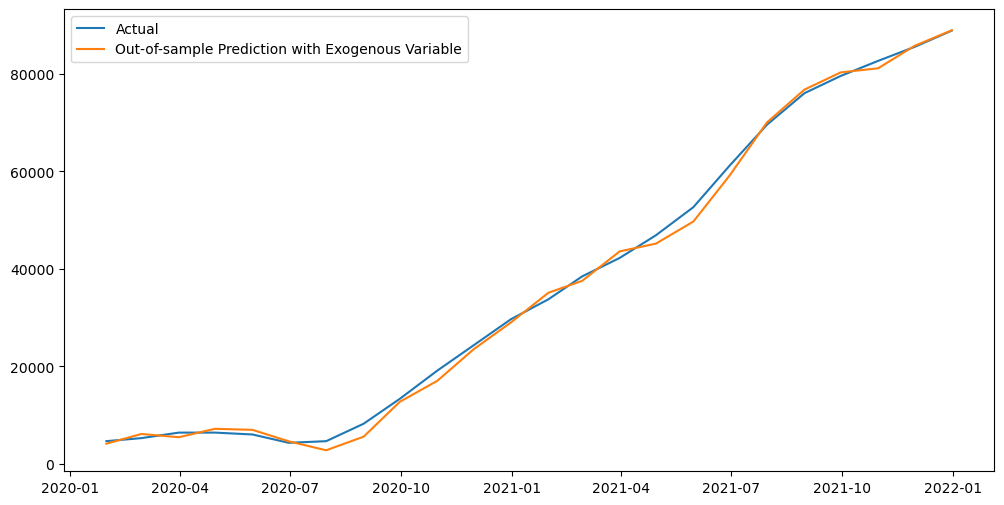

ARIMA(1,0,10) with Exogenous Variable
Mean Squared Error (In-sample): 10.727219442565556
Mean Squared Error (Out-of-sample): 1.8232082181238563


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


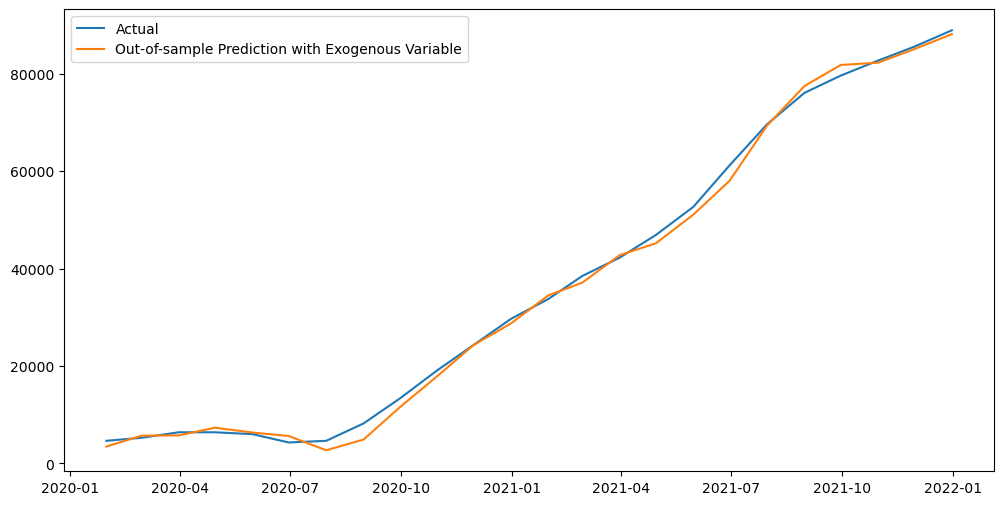

ARIMA(2,0,1) with Exogenous Variable
Mean Squared Error (In-sample): 10.782307528714677
Mean Squared Error (Out-of-sample): 2.124825058015579


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting par

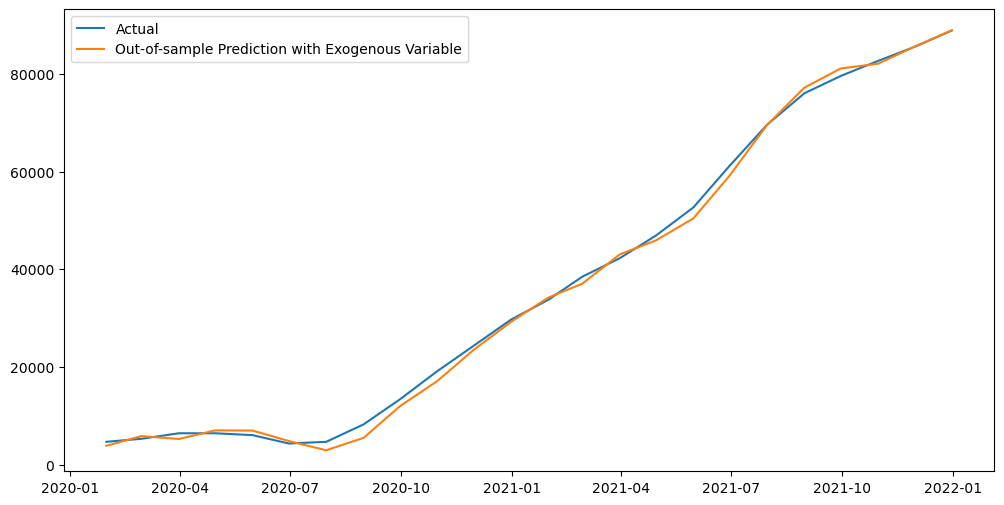

ARIMA(2,0,5) with Exogenous Variable
Mean Squared Error (In-sample): 10.7359503898142
Mean Squared Error (Out-of-sample): 1.6038732588253395


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertib

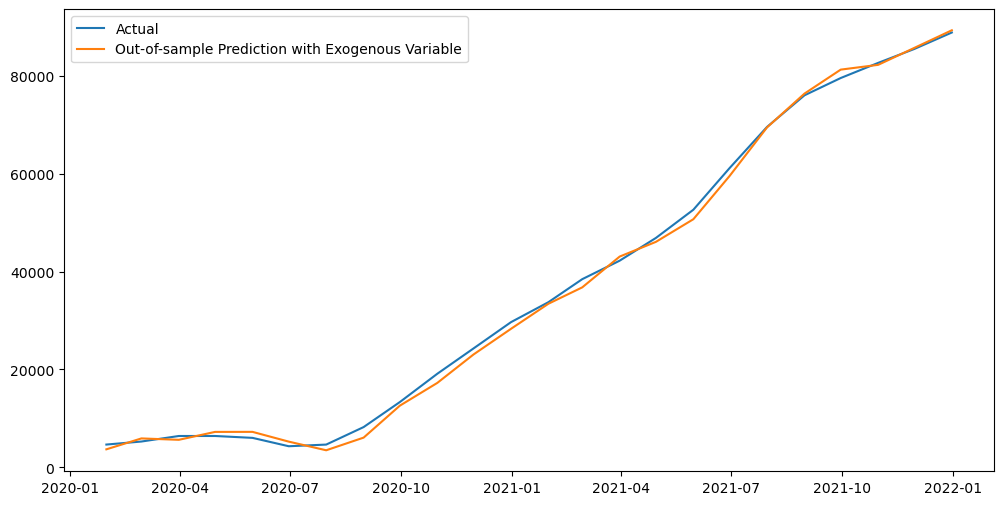

ARIMA(2,0,10) with Exogenous Variable
Mean Squared Error (In-sample): 10.649603172448176
Mean Squared Error (Out-of-sample): 1.3597689498186976


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


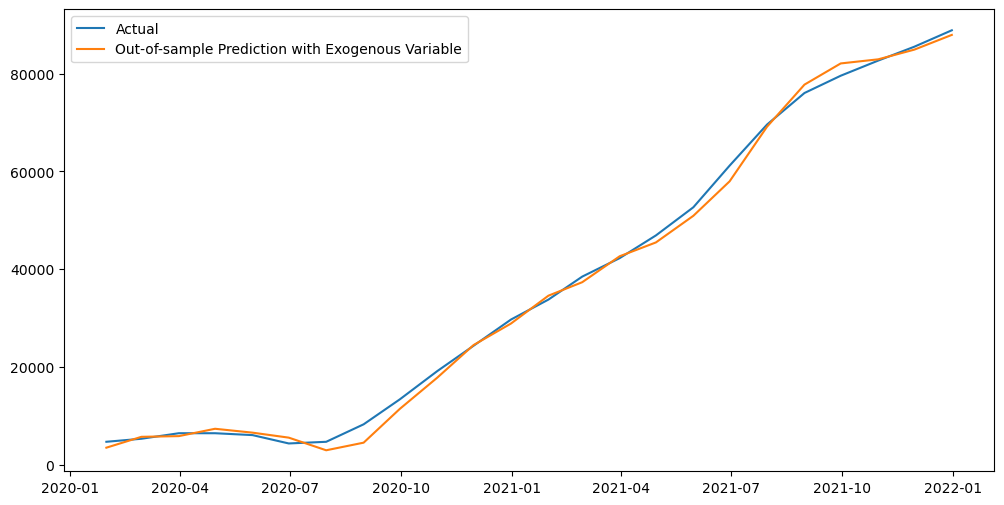

ARIMA(3,0,1) with Exogenous Variable
Mean Squared Error (In-sample): 12.256514754389288
Mean Squared Error (Out-of-sample): 2.3408424148806897


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting par

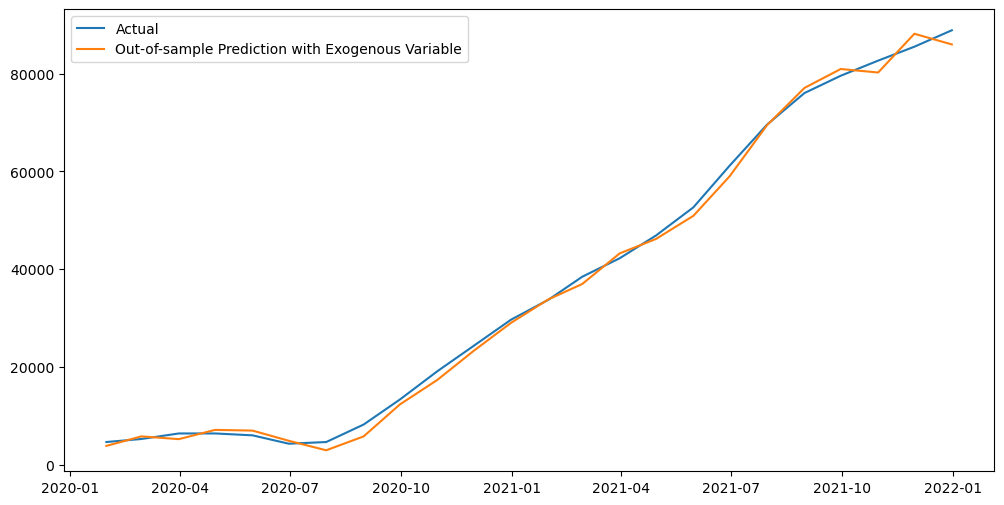

ARIMA(3,0,5) with Exogenous Variable
Mean Squared Error (In-sample): 10.663111902888271
Mean Squared Error (Out-of-sample): 2.2567629669471327


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


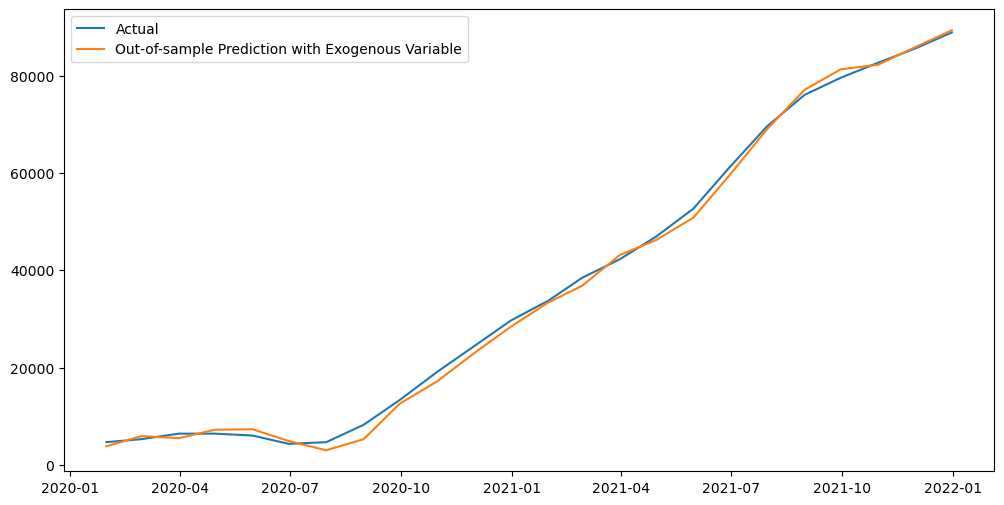

ARIMA(3,0,10) with Exogenous Variable
Mean Squared Error (In-sample): 10.643842508623758
Mean Squared Error (Out-of-sample): 1.6302479562933452


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


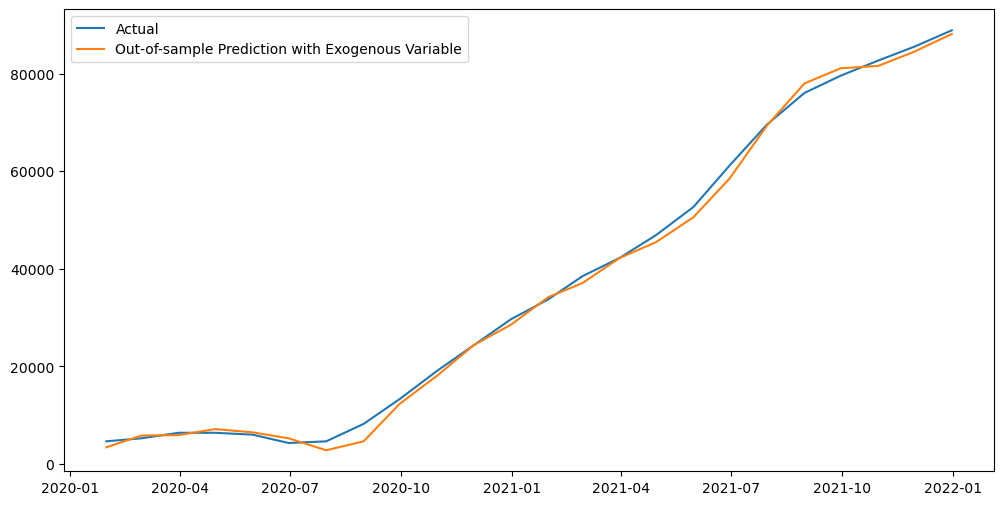

ARIMA(4,0,1) with Exogenous Variable
Mean Squared Error (In-sample): 10.77948396310484
Mean Squared Error (Out-of-sample): 1.9902664203259268


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting par

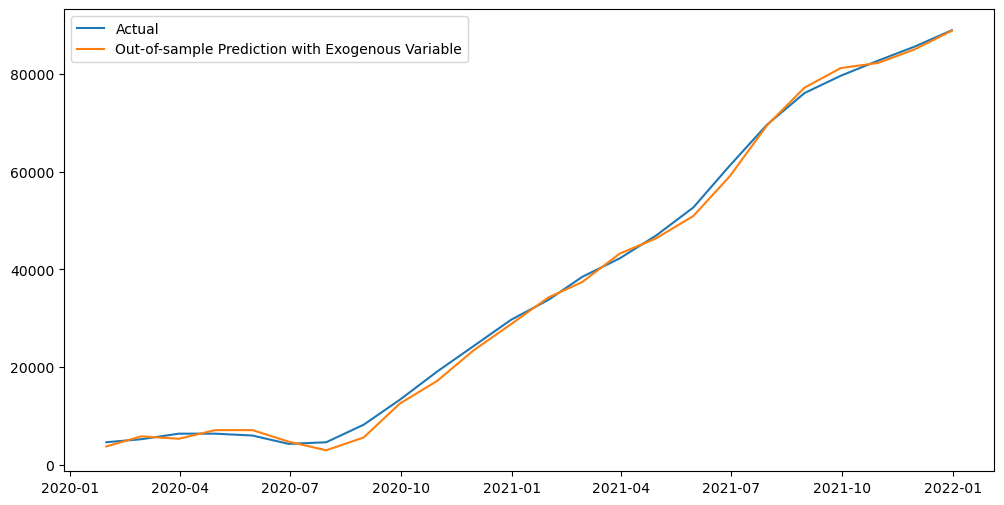

ARIMA(4,0,5) with Exogenous Variable
Mean Squared Error (In-sample): 10.660278579377033
Mean Squared Error (Out-of-sample): 1.4226726898918052


c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Weld_\anaconda3\envs\analytical\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


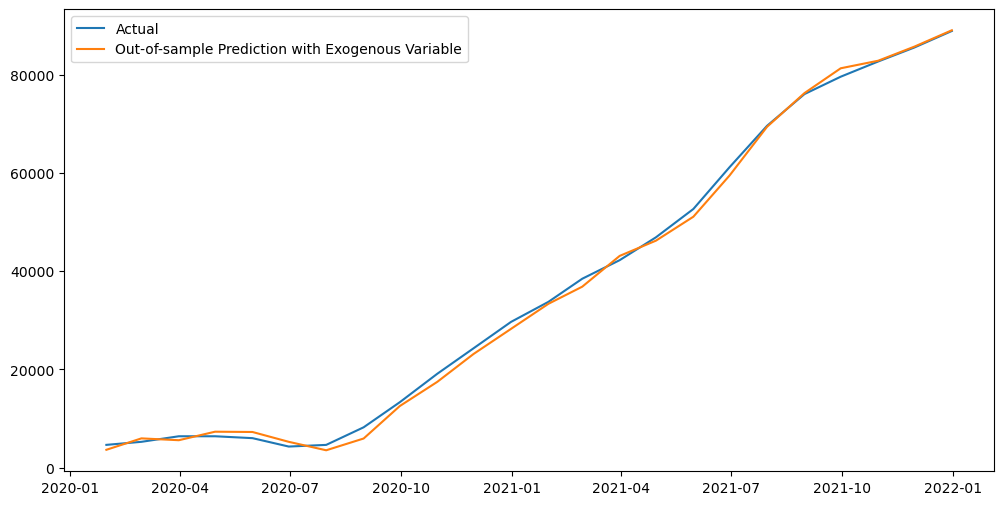

ARIMA(4,0,10) with Exogenous Variable
Mean Squared Error (In-sample): 10.647437518085903
Mean Squared Error (Out-of-sample): 1.291281760748231


In [7]:
train_ols = df_house.loc['01-01-2010':'12-31-2019'].copy()
train_ols['trend'] = np.arange(1, len(train_ols) + 1)
X = train_ols[['trend']]
y = train_ols['Price']
X = sm.add_constant(X)
model = OLS(y,X).fit()
detrended_train = model.resid
detrended_test = df_house.loc['01-01-2020':'12-31-2021']['Price'] - (model.params[0] + model.params[1] * np.arange(len(train_ols) + 1, len(train_ols) + 1 + len(df_house.loc['01-01-2020':'12-31-2021'])))
detrended = pd.concat([detrended_train, detrended_test])
prediction = {}
train = detrended['01-01-2010':'12-31-2019']
test = detrended['01-01-2020':'12-31-2021']
for p in range(1,5):
    for q in [1,5,10]:
        model = ARIMA(detrended_train,trend='n',exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':'12-31-2019'], order=(p,0,q)).fit()
        in_sample_pred = model.fittedvalues
        prediction = {}
        for i in range(len(detrended_test)):
            model = ARIMA(endog = detrended.iloc[:len(detrended_train) + i],order=(p,0,q),trend='n', exog=df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':].iloc[:len(detrended_train) + i]
              ).fit()
            pred = model.forecast(steps=1, exog= df_interest_monthly['MORTGAGE30US'].loc['01-01-2010':].iloc[len(detrended_train) + i:len(detrended_train) + i + 1])
            prediction[pred.index[0]] = pred.values[0]
        df_pred = pd.Series(prediction)
        plt.figure(figsize=(12,6))
        plt.plot(detrended_test['01-01-2020':'12-31-2021'], label='Actual')
        plt.plot(df_pred, label='Out-of-sample Prediction with Exogenous Variable')
        plt.legend()
        plt.show()
        print(f'ARIMA({p},0,{q}) with Exogenous Variable')
        print("Mean Squared Error (In-sample):", mean_squared_error(detrended_train, in_sample_pred['01-01-2010':'12-31-2019'])/1000000)
        print("Mean Squared Error (Out-of-sample):", mean_squared_error(detrended_test['01-01-2020':'12-31-2021'], df_pred['01-01-2020':'12-31-2021'])/1000000)
        warnings.simplefilter("ignore", ConvergenceWarning)